# Duffing Oscillator: A Computational Study of Nonlinear Dynamics and Chaos

## A Structured Numerical Investigation using Runge–Kutta (RK4)

---

### Contents

1. Preface and Objective
2. Introduction 
3. Physical Description of the System  
4. Mathematical Formulation  
5. Conversion to First-Order System  
6. Numerical Method (RK4)  
7. Computational Implementation  
8. Simulation Results  
   - Resonance Analysis 
   - Time Series Analysis
   - Phase Space Analysis
   - Poincaré Section  
   - Bifurcation Diagram  
9. Analysis and Observations  
10. Assumptions and Limitations  
11. Conclusion  
12. Future Work  
13. Closing Remarks  

## Preface and Objective

This project presents a computational study of the Duffing oscillator, a nonlinear dynamical system exhibiting complex behavior including periodic motion and chaos.

The goal is not only to simulate the system, but to understand how complexity and chaos emerge from simple physical laws. The project integrates physics, mathematics, and computation into a unified framework.

This work is designed as a self-contained study, combining theoretical formulation, numerical methods, and visual analysis. 

The system is analyzed using numerical integration (Runge–Kutta 4 method), and its behavior is visualized through time series, phase space, and Poincaré sections.

## Introduction

Nonlinear dynamical systems are systems whose behavior cannot be described by simple linear relationships. Unlike linear systems, they can exhibit complex phenomena such as bifurcations and chaos.

The Duffing oscillator is one of the simplest nonlinear systems that demonstrates such behavior. It consists of a mass attached to a nonlinear spring, subjected to damping and external forcing.

The Duffing oscillator is a nonlinear driven dynamical system that exhibits rich behavior including periodic motion, bifurcations, and chaos due to the interplay of damping, external forcing, and nonlinear restoring forces.

This project aims to:
- Model the Duffing oscillator mathematically 
- Solve it numerically using RK4 method (ODE)
- Analyze its behavior under different parameters and use visualisation tools


## Physical System Description

The system consists of:

- A mass attached to a spring
- Damping (frictional force)
- External periodic driving force
- Nonlinear restoring force

For small displacements, the system behaves like a normal oscillator.
For larger displacements, nonlinear effects dominate, leading to complex dynamics.

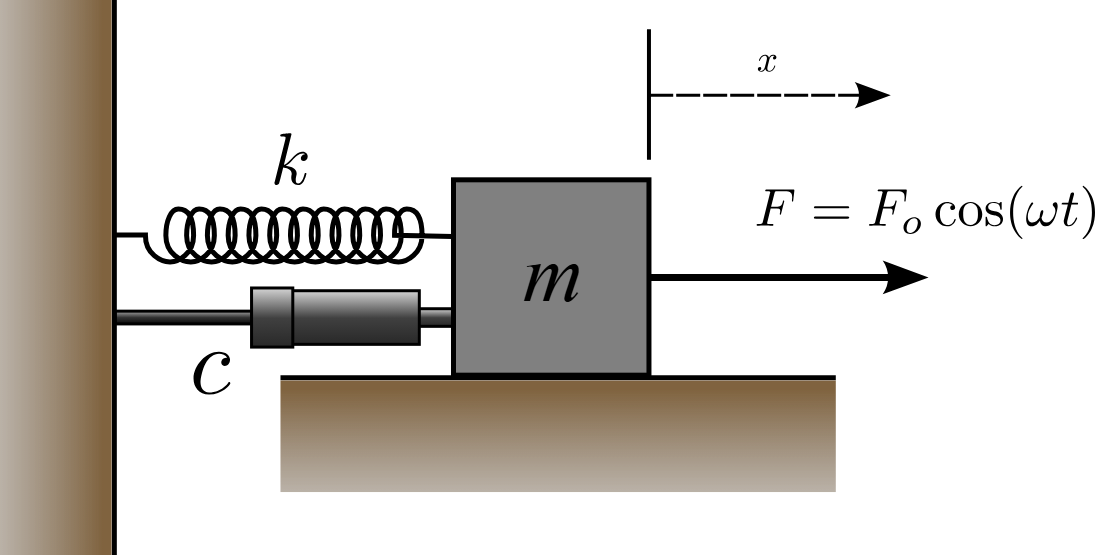

## Mathematical Model

The Duffing equation is given by:

x'' + δx' + αx + βx³ = γ cos(ωt)

Where:

- x(t): displacement
- δ: damping coefficient 
- α: linear stiffness
- β: nonlinear stiffness
- γ: forcing amplitude
- ω: forcing frequency

This is a second-order nonlinear differential equation.

## Conversion to First-Order System

To solve numerically, we convert into two first-order equations:

Let:
x₁ = x  
x₂ = v = dx/dt  

Then:

dx/dt = v  
dv/dt = -δv - αx - βx³ + γ cos(ωt)

This form is suitable for numerical integration.

## Numerical Method: Runge–Kutta (RK4)

The RK4 method improves accuracy by estimating slopes at 4 points:

- k1: slope at beginning
- k2: slope at midpoint
- k3: improved midpoint
- k4: slope at end

Final update is a weighted average:

x_next = x + (k1 + 2k2 + 2k3 + k4)/6

This provides higher accuracy than Euler’s method.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parameter Selection

We choose parameters that allow observation of nonlinear and chaotic behavior.


In [2]:
# PARAMETERS
delta = 0.2     # damping
alpha = -1.0    # linear term (negative → double well)
beta  = 1.0     # nonlinear term
gamma = 0.3     # forcing amplitude
omega = 1.2     # driving frequency

## Time Discretization

We simulate the system over a long time with small time steps.

In [3]:
dt = 0.01
t_max = 200
t = np.arange(0, t_max, dt)

## Initialization

We define arrays for position and velocity and set initial conditions.

In [4]:
x = np.zeros(len(t))
v = np.zeros(len(t))

x[0] = 0.1
v[0] = 0.0

## Acceleration Function (System Dynamics)

This represents the forces acting on the system.


In [5]:
def acceleration(x, v, t):
    return -delta*v - alpha*x - beta*x**3 + gamma*np.cos(omega*t)

## RK4 Integration Loop

We numerically solve the system step-by-step.

In [6]:
for i in range(len(t)-1):
    
    k1x = v[i]
    k1v = acceleration(x[i], v[i], t[i])

    k2x = v[i] + 0.5*k1v*dt
    k2v = acceleration(x[i] + 0.5*k1x*dt,
                       v[i] + 0.5*k1v*dt,
                       t[i] + 0.5*dt)

    k3x = v[i] + 0.5*k2v*dt
    k3v = acceleration(x[i] + 0.5*k2x*dt,
                       v[i] + 0.5*k2v*dt,
                       t[i] + 0.5*dt)

    k4x = v[i] + k3v*dt
    k4v = acceleration(x[i] + k3x*dt,
                       v[i] + k3v*dt,
                       t[i] + dt)

    x[i+1] = x[i] + (dt/6)*(k1x + 2*k2x + 2*k3x + k4x)
    v[i+1] = v[i] + (dt/6)*(k1v + 2*k2v + 2*k3v + k4v)

## Resonance Analysis
Resonance happens when The external driving frequency (ω) matches the system’s natural tendency, the amplitude increases. 
Unlike simple oscillator:
Resonance is not sharp
It can be:
- shifted
- distorted
- multi-valued

Because of nonlinearity (x³ term)

We vary the driving frequency (ω) and observe how the amplitude of oscillation changes.

Resonance occurs when the system absorbs maximum energy from the external force.

This plot, for each frequency:
- Runs full simulation
- Ignores transient
- Measures final amplitude

The peak shows resonance, skewed curve shows nonlinearity, multiples peaks shows complex dynamics 

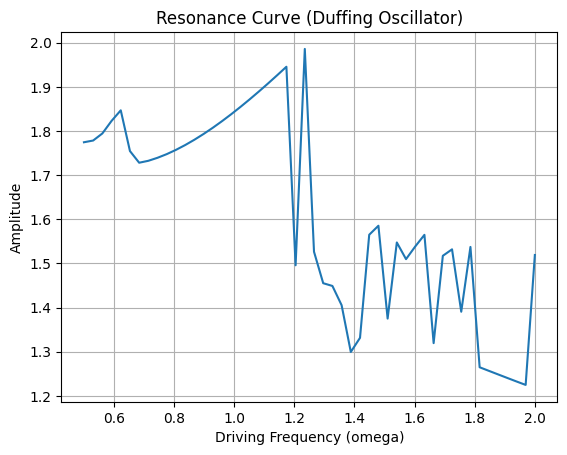

In [11]:
# RANGE OF FREQUENCIES
omegas = np.linspace(0.5, 2.0, 50)

amplitudes = []

for w in omegas:
    
    omega = w
    
    # RESET ARRAYS
    x_temp = np.zeros(len(t))
    v_temp = np.zeros(len(t))
    
    x_temp[0] = 0.1
    v_temp[0] = 0.0
    
    # RK4 SIMULATION
    for i in range(len(t)-1):

        k1x = v_temp[i]
        k1v = -delta*v_temp[i] - alpha*x_temp[i] - beta*x_temp[i]**3 + gamma*np.cos(omega*t[i])

        k2x = v_temp[i] + 0.5*k1v*dt
        k2v = -delta*(v_temp[i] + 0.5*k1v*dt) - alpha*(x_temp[i] + 0.5*k1x*dt) \
              - beta*(x_temp[i] + 0.5*k1x*dt)**3 + gamma*np.cos(omega*(t[i]+0.5*dt))

        k3x = v_temp[i] + 0.5*k2v*dt
        k3v = -delta*(v_temp[i] + 0.5*k2v*dt) - alpha*(x_temp[i] + 0.5*k2x*dt) \
              - beta*(x_temp[i] + 0.5*k2x*dt)**3 + gamma*np.cos(omega*(t[i]+0.5*dt))

        k4x = v_temp[i] + k3v*dt
        k4v = -delta*(v_temp[i] + k3v*dt) - alpha*(x_temp[i] + k3x*dt) \
              - beta*(x_temp[i] + k3x*dt)**3 + gamma*np.cos(omega*(t[i]+dt))

        x_temp[i+1] = x_temp[i] + (dt/6)*(k1x + 2*k2x + 2*k3x + k4x)
        v_temp[i+1] = v_temp[i] + (dt/6)*(k1v + 2*k2v + 2*k3v + k4v)
    
    # TAKE STEADY-STATE AMPLITUDE
    amp = np.max(np.abs(x_temp[-2000:]))
    amplitudes.append(amp)

# PLOT RESONANCE CURVE
plt.plot(omegas, amplitudes)
plt.xlabel("Driving Frequency (omega)")
plt.ylabel("Amplitude")
plt.title("Resonance Curve (Duffing Oscillator)")
plt.grid()
plt.show()

### Interpretation from this plot

The resonance curve is asymmetric due to nonlinearity.

Unlike linear systems, the Duffing oscillator shows:
- Shifted resonance peaks
- Multiple stable states
- Hysteresis-like behavior

This highlights the effect of nonlinear restoring forces.

## Time Series Analysis

This shows how displacement evolves over time.

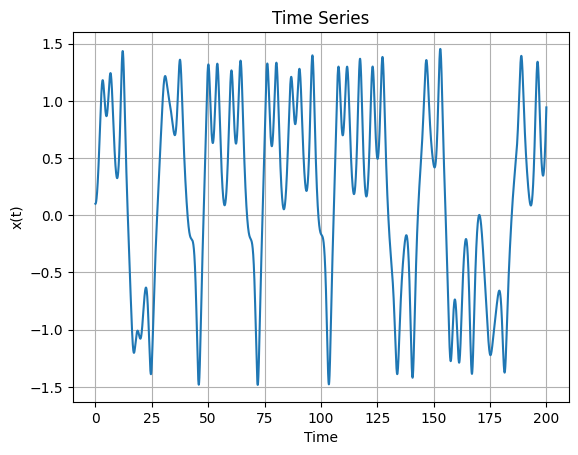

In [7]:
plt.figure()
plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Time Series")
plt.grid()
plt.show()

## Phase Space Analysis

Phase space shows system behavior in (x, v).
Closed loop symbolises simple oscillation, multiple loop symbolises complex oscillation,spiral shows damping, dense attractors symbolises chaotic system.

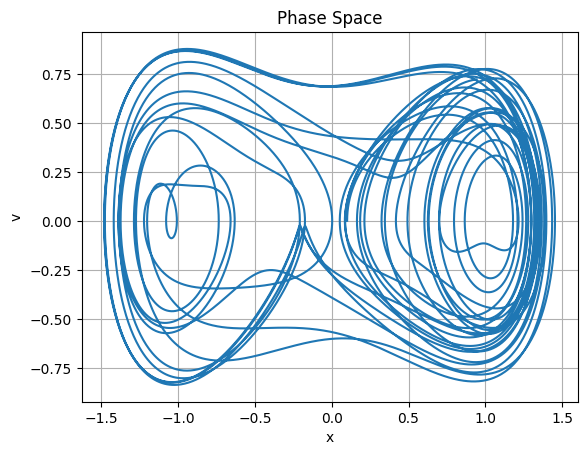

In [8]:
plt.figure()
plt.plot(x, v)
plt.xlabel("x")
plt.ylabel("v")
plt.title("Phase Space")
plt.grid()
plt.show()

## Poincaré Section

We sample the system at intervals of the driving period.

This helps identify periodic vs chaotic behavior.

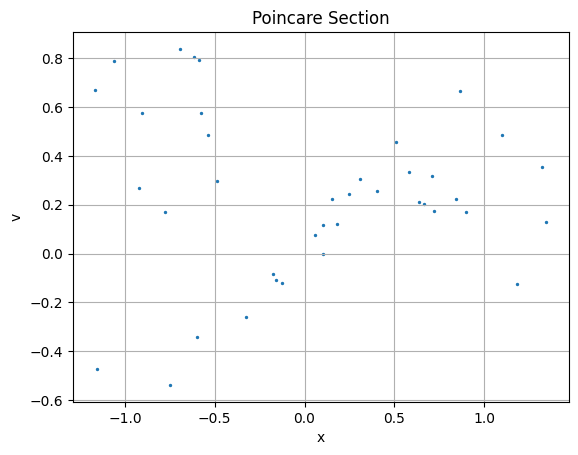

In [9]:
T = 2*np.pi / omega
indices = (t % T) < dt

plt.figure()
plt.scatter(x[indices], v[indices], s=2)
plt.xlabel("x")
plt.ylabel("v")
plt.title("Poincare Section")
plt.grid()
plt.show()

## Bifurcation Diagram

We vary the forcing amplitude (γ) and observe long-term behavior.

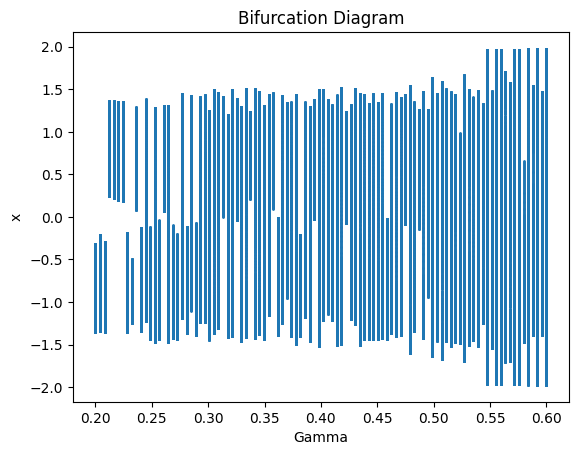

In [10]:
gammas = np.linspace(0.2, 0.6, 100)
x_vals = []

for g in gammas:
    gamma = g
    
    x_temp = np.zeros(len(t))
    v_temp = np.zeros(len(t))
    x_temp[0] = 0.1
    
    for i in range(len(t)-1):
        a = -delta*v_temp[i] - alpha*x_temp[i] - beta*x_temp[i]**3 + g*np.cos(omega*t[i])
        v_temp[i+1] = v_temp[i] + a*dt
        x_temp[i+1] = x_temp[i] + v_temp[i]*dt
    
    x_vals.extend(x_temp[-1000:])

plt.scatter(np.repeat(gammas, 1000), x_vals, s=1)
plt.xlabel("Gamma")
plt.ylabel("x")
plt.title("Bifurcation Diagram")
plt.show()

## Observations

- For small forcing, motion is periodic
- Increasing forcing leads to complex oscillations
- At higher forcing, chaotic behavior emerges, chaotic attractors appear
- For small γ, motion is periodic
- Increasing γ leads to bifurcation (periodic to complex to chaotic)
- System is periodic, deterministic and predictable though looks random as its extremely sensitive to initial    conditions, quasi-periodic.
- The driving force adds energy, damping force removes energy, the system reaches dynamic equilibrium and nonlinearity redistributes energy
- The non-linear term in restoring force breaks symmetry and creates multiple equilibrium states causing chaos and bifurcation 
- Small angle oscillation is comparatively linear than large angle oscillation
- The phase space analysis shows strange attractor, chaos. Phase space becomes spiral, dense and complex.
- When omega is changed, small amplitude leads to off resonance, large amplitude leads to near resonance and sudden jumps gives nonlinear effects
- Changing initial conditions x[0] from 0.1 to 0.1001, the result diverges, indicating chaos 


The phase space becomes irregular and dense, indicating chaos.


## Assumptions and Limitations 

- Mass is taken as unity
- System is deterministic
- External force is sinusoidal
- No stochastic noise included
- Numerical errors may accumulate 
- Despite simplifications, the model captures essential nonlinear behavior.

## Conclusion

The Duffing oscillator demonstrates how simple nonlinear systems can produce rich and complex dynamics.

Using RK4, we successfully simulated the system and observed:
- Periodic motion
- Transition behavior
- Chaos

This highlights the importance of numerical methods in studying nonlinear physics.

## Future Work

- Lyapunov exponent calculation
- Energy analysis
- Animation of system motion
- Higher dimensional systems 


## Closing Remarks

This project illustrates the deep connection between simple physical laws and complex emergent behavior.

It serves as a foundation for further exploration into nonlinear dynamics, chaos theory, and computational physics.

---